# agentv18_a2a_communication — Agent-to-Agent over HTTP

This version introduces a host LangGraph agent communicating with remote specialist agents.

Architecture:

```text
Host LangGraph Agent
   ├── HTTP → SQL Agent Server
   └── HTTP → RAG Agent Server
```


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter fastapi uvicorn httpx
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter fastapi uvicorn httpx


## 2. Start specialist agent servers

In separate terminals:

```bash
python -m agentv18_a2a_communication.sql_agent_server
```

```bash
python -m agentv18_a2a_communication.rag_agent_server
```

SQL Agent URL:

```text
http://127.0.0.1:8101/analyze
```

RAG Agent URL:

```text
http://127.0.0.1:8102/analyze
```


## 3. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

SQL_AGENT_URL = os.getenv("SQL_AGENT_URL", "http://127.0.0.1:8101/analyze")
RAG_AGENT_URL = os.getenv("RAG_AGENT_URL", "http://127.0.0.1:8102/analyze")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("SQL Agent URL:", SQL_AGENT_URL)
print("RAG Agent URL:", RAG_AGENT_URL)


OpenAI API key present: True
LangSmith tracing: true
SQL Agent URL: http://127.0.0.1:8101/analyze
RAG Agent URL: http://127.0.0.1:8102/analyze


## 4. Define state using NotRequired


In [3]:
from typing import NotRequired, TypedDict

class AgentState(TypedDict):
    input: str
    plan: NotRequired[str]
    sql_agent_result: NotRequired[str]
    rag_agent_result: NotRequired[str]
    final_answer: NotRequired[str]


## 5. Define remote agent client


In [4]:
import httpx

async def call_remote_agent(url: str, task: str) -> str:
    async with httpx.AsyncClient(timeout=30.0) as client:
        response = await client.post(url, json={"task": task})
        response.raise_for_status()
        payload = response.json()

    return f"{payload['agent_name']}: {payload['analysis']}"


## 6. Test remote agents directly


In [5]:
sql_test = await call_remote_agent(
    SQL_AGENT_URL,
    "Investigate CHECK-DOMAIN timeout spike after R13",
)

rag_test = await call_remote_agent(
    RAG_AGENT_URL,
    "Investigate CHECK-DOMAIN timeout spike after R13",
)

print(sql_test)
print()
print(rag_test)


sql_agent: SQL Agent Analysis: Structured metrics indicate CHECK-DOMAIN timeout volume increased after release R13. The strongest signal is elevated CONNECTION_TIMEOUT failures for client_b and p95 response_time around 240 ms during peak traffic. Task: Investigate CHECK-DOMAIN timeout spike after R13

rag_agent: RAG Agent Analysis: Runbook and R13 release notes indicate connection pool saturation is a known CHECK-DOMAIN latency risk. Recommended checks include upstream registry endpoint health, DNS resolver latency, and registry connectivity. Task: Investigate CHECK-DOMAIN timeout spike after R13


## 7. Define host graph nodes


In [6]:
import asyncio
from langchain_openai import ChatOpenAI

async def planner_node(state: AgentState) -> AgentState:
    return {
        "plan": (
            "Delegate structured metrics analysis to SQL Agent and document/runbook "
            "analysis to RAG Agent, then synthesize the combined result."
        )
    }

async def call_sql_agent_node(state: AgentState) -> AgentState:
    result = await call_remote_agent(SQL_AGENT_URL, state["input"])
    return {"sql_agent_result": result}

async def call_rag_agent_node(state: AgentState) -> AgentState:
    result = await call_remote_agent(RAG_AGENT_URL, state["input"])
    return {"rag_agent_result": result}

async def synthesize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
User request:
{state["input"]}

Plan:
{state["plan"]}

SQL specialist result:
{state["sql_agent_result"]}

RAG specialist result:
{state["rag_agent_result"]}

Write a concise final incident analysis with:
1. likely cause
2. evidence from both agents
3. recommended next action
'''

    response = await llm.ainvoke(prompt)
    return {"final_answer": response.content}


## 8. Build host graph with parallel A2A calls


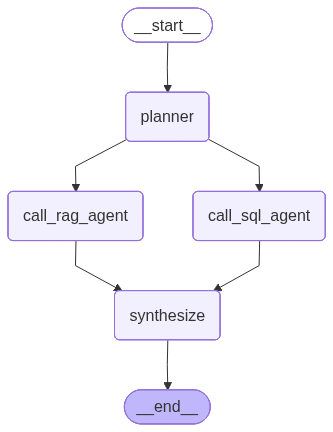

In [7]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("planner", planner_node)
    graph_builder.add_node("call_sql_agent", call_sql_agent_node)
    graph_builder.add_node("call_rag_agent", call_rag_agent_node)
    graph_builder.add_node("synthesize", synthesize_node)

    graph_builder.add_edge(START, "planner")

    graph_builder.add_edge("planner", "call_sql_agent")
    graph_builder.add_edge("planner", "call_rag_agent")

    graph_builder.add_edge("call_sql_agent", "synthesize")
    graph_builder.add_edge("call_rag_agent", "synthesize")

    graph_builder.add_edge("synthesize", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 9. Visualize graph


In [8]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	call_sql_agent(call_sql_agent)
	call_rag_agent(call_rag_agent)
	synthesize(synthesize)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	call_rag_agent --> synthesize;
	call_sql_agent --> synthesize;
	planner --> call_rag_agent;
	planner --> call_sql_agent;
	synthesize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 10. Visualize PNG


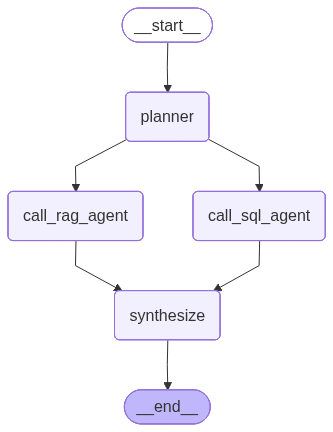

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed:", e)


## 11. Run host agent


In [10]:
result = await graph.ainvoke({
    "input": "Investigate CHECK-DOMAIN timeout spike after R13 using metrics and docs."
})

print(result["final_answer"])


### Incident Analysis: CHECK-DOMAIN Timeout Spike After R13

**1. Likely Cause:**
The spike in CHECK-DOMAIN timeouts following release R13 is likely due to connection pool saturation, which has been identified as a risk factor for increased latency in CHECK-DOMAIN operations. This saturation may have been exacerbated by elevated traffic levels and potential issues with upstream registry endpoint health or DNS resolver latency.

**2. Evidence from Both Agents:**
- **SQL Agent Findings:** The structured metrics analysis revealed a significant increase in CONNECTION_TIMEOUT failures for client_b, with the 95th percentile (p95) response time reaching approximately 240 ms during peak traffic periods. This indicates that the system is struggling to handle requests efficiently, leading to timeouts.
  
- **RAG Agent Findings:** The runbook and release notes from R13 confirm that connection pool saturation is a known risk for CHECK-DOMAIN latency. The agent recommended checks on upstream regist

## 12. Inspect specialist outputs


In [11]:
print("SQL RESULT:")
print(result["sql_agent_result"])
print()
print("RAG RESULT:")
print(result["rag_agent_result"])


SQL RESULT:
sql_agent: SQL Agent Analysis: Structured metrics indicate CHECK-DOMAIN timeout volume increased after release R13. The strongest signal is elevated CONNECTION_TIMEOUT failures for client_b and p95 response_time around 240 ms during peak traffic. Task: Investigate CHECK-DOMAIN timeout spike after R13 using metrics and docs.

RAG RESULT:
rag_agent: RAG Agent Analysis: Runbook and R13 release notes indicate connection pool saturation is a known CHECK-DOMAIN latency risk. Recommended checks include upstream registry endpoint health, DNS resolver latency, and registry connectivity. Task: Investigate CHECK-DOMAIN timeout spike after R13 using metrics and docs.


## 13. Stream host graph updates


In [12]:
async for chunk in graph.astream(
    {"input": "Investigate CHECK-DOMAIN timeout spike after R13 using metrics and docs."},
    stream_mode="updates",
):
    print("\n--- update ---")
    print(chunk)



--- update ---
{'planner': {'plan': 'Delegate structured metrics analysis to SQL Agent and document/runbook analysis to RAG Agent, then synthesize the combined result.'}}

--- update ---
{'call_sql_agent': {'sql_agent_result': 'sql_agent: SQL Agent Analysis: Structured metrics indicate CHECK-DOMAIN timeout volume increased after release R13. The strongest signal is elevated CONNECTION_TIMEOUT failures for client_b and p95 response_time around 240 ms during peak traffic. Task: Investigate CHECK-DOMAIN timeout spike after R13 using metrics and docs.'}}

--- update ---
{'call_rag_agent': {'rag_agent_result': 'rag_agent: RAG Agent Analysis: Runbook and R13 release notes indicate connection pool saturation is a known CHECK-DOMAIN latency risk. Recommended checks include upstream registry endpoint health, DNS resolver latency, and registry connectivity. Task: Investigate CHECK-DOMAIN timeout spike after R13 using metrics and docs.'}}

--- update ---
{'synthesize': {'final_answer': '### Inci

## 14. A2A vs MCP

MCP exposes tools.

A2A exposes agents.

```text
MCP: call get_cloudwatch_metrics()
A2A: delegate incident investigation to CloudOps Agent
```

Both patterns are useful in production.
